# AI-Powered Behavioral Anomaly Detection for Cybersecurity
### Honeywell Hackathon — SOC-style Anomaly Detection Pipeline

This notebook builds an end-to-end behavioral anomaly detection system:

1. **EDA** on the login-event dataset
2. **Preprocessing & feature engineering**
3. **Unsupervised Isolation Forest** trained only on normal behavior (detects "is this anomalous?")
4. **Supervised classifier (XGBoost)** trained only on attack events (detects "what kind of attack?")
5. **Inference pipeline** that turns a single raw login event into a `prediction / risk_score / confidence / reasons` JSON, like a real SOC alert
6. **Explainability** via SHAP, so every flag has a "why"

Design rationale is explained in markdown next to each step — this mirrors how a real detection engineering team would document a model for a SOC.

## 1. Imports & Configuration

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, accuracy_score, roc_curve
)
from xgboost import XGBClassifier
import shap

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

RANDOM_STATE = 42
DATA_PATH = "data/behavior_anomaly_training_dataset.xlsx"
MODEL_DIR = "saved_models"
os.makedirs(MODEL_DIR, exist_ok=True)

print("Environment ready.")

Environment ready.


## 2. Load Dataset

The dataset is loaded automatically from the Excel file. No manual copy/paste — this cell is the single source of truth for data ingestion, so the pipeline can be pointed at a new export by only changing `DATA_PATH`.

In [2]:
df = pd.read_excel(DATA_PATH)
print(f"Shape: {df.shape}")
df.head(10)

Shape: (10000, 19)


,event_id,timestamp,user_id,department,location,country,device,os,browser,resource,login_hour,failed_attempts,new_device,country_changed,travel_speed_kmph,session_duration_min,unique_resources,attack_type,label
0,E000001,2026-07-05T23:57:00,U0655,Finance,Chennai,India,MacBook Pro,Windows 11,Edge,Payroll,23,0,0,0,0,32,5,NaN,0
1,E000002,2026-07-10T09:11:00,U0031,Finance,Bangalore,India,HP EliteBook,macOS,Chrome,GitLab,9,0,0,0,0,176,5,NaN,0
2,E000003,2026-07-13T23:30:00,U0460,Sales,Hyderabad,India,Dell Latitude,Windows 11,Safari,Finance Portal,23,1,0,0,0,96,1,NaN,0
3,E000004,2026-07-07T00:20:00,U0100,IT,Hyderabad,India,MacBook Pro,Windows 11,Safari,GitLab,0,2,0,0,0,106,1,NaN,0
4,E000005,2026-07-04T11:58:00,U0850,Engineering,Delhi,India,MacBook Pro,macOS,Edge,CRM,11,1,0,0,0,84,1,NaN,0
5,E000006,2026-07-18T04:20:00,U0888,Finance,Mumbai,India,MacBook Pro,Windows 10,Firefox,Payroll,4,0,0,0,0,100,2,NaN,0
6,E000007,2026-07-22T08:54:00,U0719,Engineering,Chennai,India,HP EliteBook,macOS,Edge,Payroll,8,0,0,0,0,173,5,NaN,0
7,E000008,2026-07-04T08:17:00,U0333,Finance,Bangalore,India,Dell Latitude,Windows 10,Safari,Finance Portal,8,2,0,0,0,64,5,NaN,0
8,E000009,2026-07-13T09:19:00,U0323,HR,Mumbai,India,Lenovo ThinkPad,macOS,Safari,Payroll,9,1,0,0,0,147,3,NaN,0
9,E000010,2026-07-23T19:03:00,U0439,Sales,Mumbai,India,MacBook Pro,Windows 11,Edge,GitLab,19,1,0,0,0,33,1,NaN,0


## 3. Exploratory Data Analysis

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   event_id              10000 non-null  str  
 1   timestamp             10000 non-null  str  
 2   user_id               10000 non-null  str  
 3   department            10000 non-null  str  
 4   location              10000 non-null  str  
 5   country               10000 non-null  str  
 6   device                10000 non-null  str  
 7   os                    10000 non-null  str  
 8   browser               10000 non-null  str  
 9   resource              10000 non-null  str  
 10  login_hour            10000 non-null  int64
 11  failed_attempts       10000 non-null  int64
 12  new_device            10000 non-null  int64
 13  country_changed       10000 non-null  int64
 14  travel_speed_kmph     10000 non-null  int64
 15  session_duration_min  10000 non-null  int64
 16  unique_resources

In [4]:
print("=== Missing values per column ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct}).sort_values("missing_count", ascending=False)

=== Missing values per column ===


,missing_count,missing_pct
attack_type,9701,97.01
timestamp,0,0.00
event_id,0,0.00
user_id,0,0.00
department,0,0.00
country,0,0.00
location,0,0.00
os,0,0.00
browser,0,0.00
resource,0,0.00


**Observation:** `attack_type` is missing for every row where `label == 0`. This is expected — a normal login has no attack type. This is **not** a data quality issue and must be handled with domain logic (`"Normal"`), not mean/median imputation.

=== Label distribution ===
label
0    9701
1     299
Name: count, dtype: int64

Attack rate: 2.99%


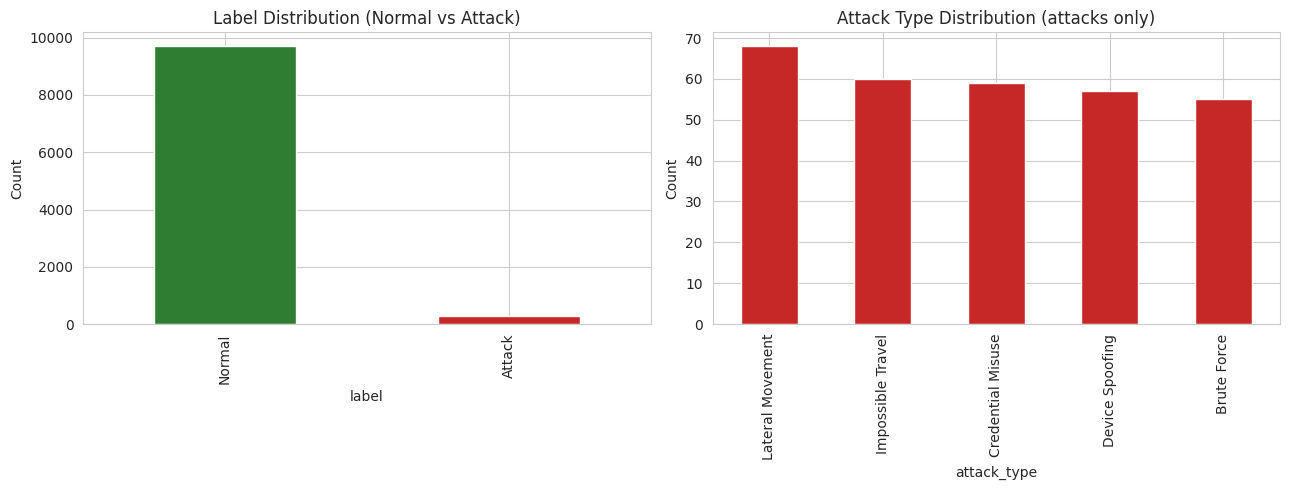

In [5]:
print("=== Label distribution ===")
print(df["label"].value_counts())
print(f"\nAttack rate: {df['label'].mean()*100:.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
df["label"].value_counts().rename({0: "Normal", 1: "Attack"}).plot(
    kind="bar", ax=axes[0], color=["#2e7d32", "#c62828"]
)
axes[0].set_title("Label Distribution (Normal vs Attack)")
axes[0].set_ylabel("Count")

df[df["label"] == 1]["attack_type"].value_counts().plot(
    kind="bar", ax=axes[1], color="#c62828"
)
axes[1].set_title("Attack Type Distribution (attacks only)")
axes[1].set_ylabel("Count")
plt.tight_layout()
plt.show()

**Observation:** The dataset is **highly imbalanced** (~3% attacks), which is realistic for real SOC telemetry. This directly motivates the architecture choice below: an unsupervised model trained on normal traffic to catch rare/novel deviations, rather than a single supervised classifier that would be starved of positive examples and biased toward the majority class.

Attack types are fairly balanced *among attacks* (~55-68 samples each), so the second-stage classifier has enough signal per class.

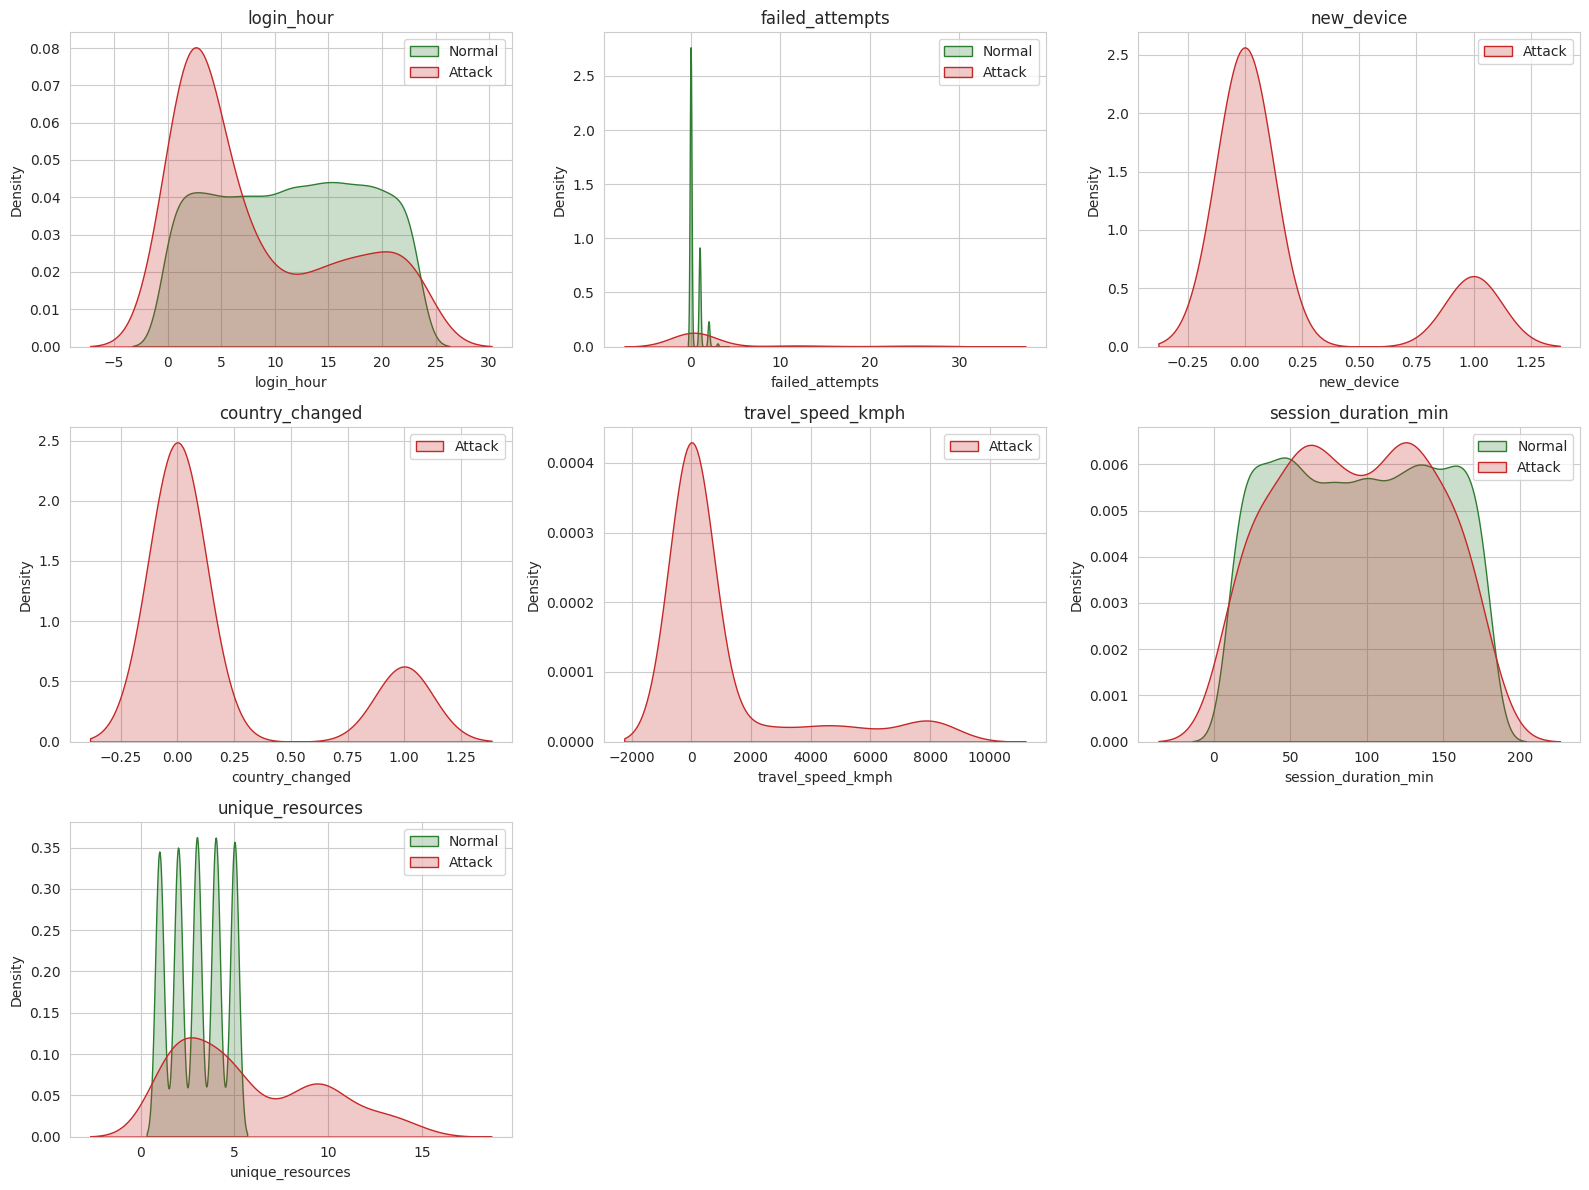

In [6]:
numeric_features = ["login_hour", "failed_attempts", "new_device", "country_changed",
                     "travel_speed_kmph", "session_duration_min", "unique_resources"]

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
for i, feat in enumerate(numeric_features):
    sns.kdeplot(df[df.label == 0][feat], ax=axes[i], label="Normal", fill=True, color="#2e7d32")
    sns.kdeplot(df[df.label == 1][feat], ax=axes[i], label="Attack", fill=True, color="#c62828")
    axes[i].set_title(feat)
    axes[i].legend()
for j in range(len(numeric_features), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

**Observation:** `failed_attempts`, `travel_speed_kmph`, `country_changed`, and `new_device` show visibly different distributions between normal and attack traffic — these are the strongest behavioral signals. `login_hour` and `session_duration_min` overlap more, meaning they'll contribute less individually but can still help in combination (e.g. off-hours + high failed attempts).

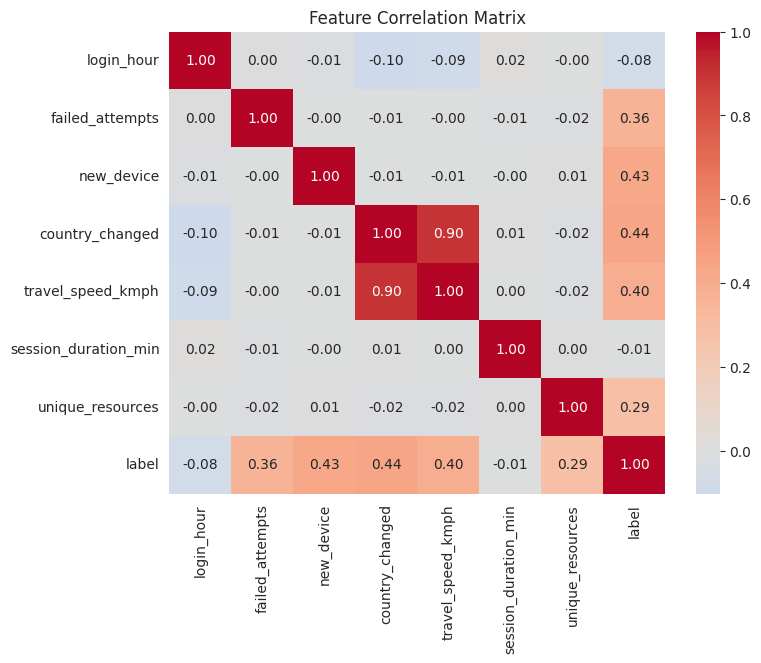

In [7]:
corr = df[numeric_features + ["label"]].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature Correlation Matrix")
plt.show()

## 4. Preprocessing & Feature Engineering

Design decisions:

- **Missing `attack_type`** → filled with `"Normal"`. This isn't a gap to impute statistically; it's a categorical fact (no attack occurred).
- **High-cardinality identifier columns** (`event_id`, `user_id`, `timestamp` string, `location`) are **dropped from the model inputs**. `user_id` in particular would let a tree-based model memorize "which users are historically attackers" in this synthetic set, which is a form of leakage that won't generalize to new users in production — a real SOC model must flag *behavior*, not identity.
- **`department`, `country`, `device`, `os`, `browser`, `resource`** are categorical but low/medium cardinality. Rather than one-hot encoding all of them (which would dilute the 7 strong numeric signals found in the EDA above and risks overfitting on ~300 attack samples), we distill the two that EDA and domain knowledge suggest matter most into engineered binary flags:
  - `is_off_hours`: login between 12 AM–5 AM (classic brute-force / credential-misuse window)
  - `sensitive_resource_access`: login touches a high-value resource (Payroll, Finance Portal)
- All engineered features stay **numeric and interpretable**, which keeps the model auditable for a SOC analyst and keeps SHAP explanations human-readable.

This logic is wrapped in a single function so it's reused identically for training and for live inference — a common source of train/serve skew in real deployments is duplicated, drifting feature logic.

In [8]:
SENSITIVE_RESOURCES = {"Payroll", "Finance Portal"}

FEATURE_COLUMNS = [
    "login_hour", "failed_attempts", "new_device", "country_changed",
    "travel_speed_kmph", "session_duration_min", "unique_resources",
    "is_off_hours", "sensitive_resource_access",
]


def engineer_features(raw_df: pd.DataFrame) -> pd.DataFrame:
    """Apply feature engineering to a raw events dataframe.

    This is the SINGLE source of truth for feature logic, used identically
    at training time and at inference time to avoid train/serve skew.

    Parameters
    ----------
    raw_df : pd.DataFrame
        Raw events with at least the columns: login_hour, failed_attempts,
        new_device, country_changed, travel_speed_kmph, session_duration_min,
        unique_resources, resource.

    Returns
    -------
    pd.DataFrame
        Dataframe containing exactly FEATURE_COLUMNS, ready for scaling.
    """
    out = raw_df.copy()

    # Missing attack_type just means "no attack" -- domain fact, not imputation
    if "attack_type" in out.columns:
        out["attack_type"] = out["attack_type"].fillna("Normal")

    # Off-hours flag: midnight - 5am is the classic low-noise attack window
    out["is_off_hours"] = out["login_hour"].apply(lambda h: 1 if (h < 5) else 0)

    # Sensitive resource access flag
    out["sensitive_resource_access"] = out["resource"].apply(
        lambda r: 1 if r in SENSITIVE_RESOURCES else 0
    )

    return out[FEATURE_COLUMNS + (["attack_type", "label"] if "label" in out.columns else [])]


df_fe = engineer_features(df)
print(f"Engineered feature set: {FEATURE_COLUMNS}")
df_fe.head()

Engineered feature set: ['login_hour', 'failed_attempts', 'new_device', 'country_changed', 'travel_speed_kmph', 'session_duration_min', 'unique_resources', 'is_off_hours', 'sensitive_resource_access']


,login_hour,failed_attempts,new_device,country_changed,travel_speed_kmph,session_duration_min,unique_resources,is_off_hours,sensitive_resource_access,attack_type,label
0,23,0,0,0,0,32,5,0,1,Normal,0
1,9,0,0,0,0,176,5,0,0,Normal,0
2,23,1,0,0,0,96,1,0,1,Normal,0
3,0,2,0,0,0,106,1,1,0,Normal,0
4,11,1,0,0,0,84,1,0,0,Normal,0


In [9]:
print("Missing values after preprocessing:")
print(df_fe.isnull().sum().sum(), "total missing values")

Missing values after preprocessing:
0 total missing values


## 5. Train/Test Split

We split the **full** dataset (normal + attack) in a stratified 80/20 split so the test set preserves the real-world ~3% attack rate — evaluating on an artificially balanced test set would overstate real-world precision/recall.

The Isolation Forest will then be fit **only on the normal rows of the training split** (see next section) — this is a deliberate architectural choice, not a mistake: it teaches the model the shape of "normal" so anything that doesn't fit is flagged, including attack patterns the model has never seen before (zero-day-style behavior), which a purely supervised classifier cannot do.

In [10]:
X = df_fe[FEATURE_COLUMNS]
y = df_fe["label"]
attack_type_full = df_fe["attack_type"]

X_train, X_test, y_train, y_test, at_train, at_test = train_test_split(
    X, y, attack_type_full,
    test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print(f"Train: {X_train.shape}, attack rate = {y_train.mean()*100:.2f}%")
print(f"Test:  {X_test.shape}, attack rate = {y_test.mean()*100:.2f}%")

Train: (8000, 9), attack rate = 2.99%
Test:  (2000, 9), attack rate = 3.00%


## 6. Feature Scaling

Isolation Forest is tree-based and technically scale-invariant, but we still scale here for two practical reasons:
1. `travel_speed_kmph` and `session_duration_min` are on very different numeric ranges than binary flags like `new_device` — scaling keeps the isolation-path-length geometry meaningful and makes the anomaly scores more stable/interpretable.
2. It future-proofs the pipeline for swapping in a distance-based model (e.g. One-Class SVM, LOF) without touching the rest of the code.

The scaler is fit **only on training data** to prevent test-set leakage, and is persisted so inference uses the exact same transform.

In [11]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=FEATURE_COLUMNS, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=FEATURE_COLUMNS, index=X_test.index)

joblib.dump(scaler, f"{MODEL_DIR}/feature_scaler.pkl")
print("Scaler fit on training data and saved.")

Scaler fit on training data and saved.


## 7. Model 1 — Isolation Forest (Unsupervised Anomaly Detection)

Trained **only on normal (label=0) training rows**. At inference time it has never seen an attack, so a low isolation-path-length (= high anomaly score) on new data means "this doesn't look like anything I was trained on" — exactly the behavior a SOC wants for catching novel attack patterns.

**Hyperparameters:**
- `n_estimators=200`: more trees than the sklearn default (100) for a more stable anomaly score on a 10k-row dataset, at acceptable extra cost.
- `contamination=<observed attack rate>`: sets the internal decision threshold to match the real-world prior we measured in EDA, rather than the arbitrary sklearn default of 0.1 (which would over-flag ~10% of normal traffic and drown a SOC analyst in false positives).
- `max_samples="auto"`, `random_state` fixed for reproducibility.

In [12]:
normal_train = X_train_scaled[y_train == 0]
contamination_rate = round(y.mean(), 4)  # observed real-world attack rate

iso_forest = IsolationForest(
    n_estimators=200,
    max_samples="auto",
    contamination=contamination_rate,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
iso_forest.fit(normal_train)

print(f"Isolation Forest trained on {len(normal_train)} normal-only samples.")
print(f"Contamination threshold set to observed attack rate: {contamination_rate}")

Isolation Forest trained on 7761 normal-only samples.
Contamination threshold set to observed attack rate: 0.0299


### 7.1 Evaluation on held-out test set (normal + attack mixed)

In [13]:
# sklearn convention: -1 = anomaly, 1 = normal -> remap to our label convention (1 = attack)
raw_pred = iso_forest.predict(X_test_scaled)
y_pred_iso = np.where(raw_pred == -1, 1, 0)

# decision_function: higher = more normal. Flip sign so higher = more anomalous,
# and use it as a continuous anomaly score for ROC-AUC and for the risk score later.
anomaly_score_test = -iso_forest.decision_function(X_test_scaled)

precision = precision_score(y_test, y_pred_iso)
recall = recall_score(y_test, y_pred_iso)
f1 = f1_score(y_test, y_pred_iso)
roc_auc = roc_auc_score(y_test, anomaly_score_test)

print("=== Isolation Forest — Test Set Performance ===")
print(f"Precision : {precision:.3f}")
print(f"Recall    : {recall:.3f}")
print(f"F1-score  : {f1:.3f}")
print(f"ROC AUC   : {roc_auc:.3f}")
print()
print(classification_report(y_test, y_pred_iso, target_names=["Normal", "Attack"]))

=== Isolation Forest — Test Set Performance ===
Precision : 0.233
Recall    : 0.283
F1-score  : 0.256
ROC AUC   : 0.769

              precision    recall  f1-score   support

      Normal       0.98      0.97      0.97      1940
      Attack       0.23      0.28      0.26        60

    accuracy                           0.95      2000
   macro avg       0.61      0.63      0.62      2000
weighted avg       0.96      0.95      0.95      2000



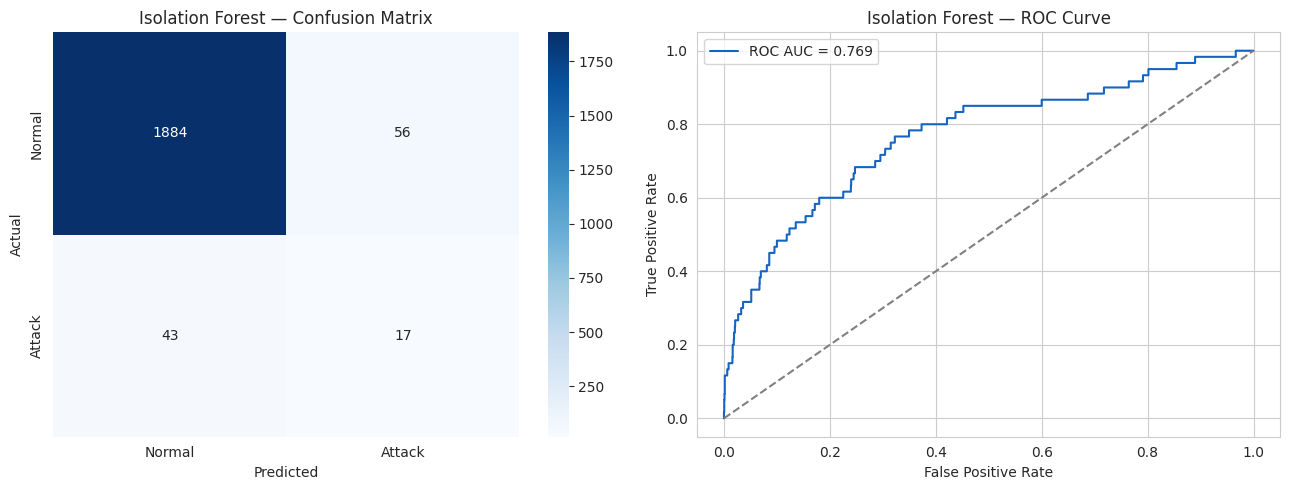

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm = confusion_matrix(y_test, y_pred_iso)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Normal", "Attack"], yticklabels=["Normal", "Attack"], ax=axes[0])
axes[0].set_title("Isolation Forest — Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

fpr, tpr, _ = roc_curve(y_test, anomaly_score_test)
axes[1].plot(fpr, tpr, label=f"ROC AUC = {roc_auc:.3f}", color="#1565c0")
axes[1].plot([0, 1], [0, 1], "--", color="gray")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("Isolation Forest — ROC Curve")
axes[1].legend()
plt.tight_layout()
plt.show()

In [15]:
joblib.dump(iso_forest, f"{MODEL_DIR}/behavior_model.pkl")
print("Isolation Forest saved to saved_models/behavior_model.pkl")

Isolation Forest saved to saved_models/behavior_model.pkl


**Honest read of these numbers:** ROC AUC of ~0.77 shows the anomaly *score* ranks attacks above normal traffic reasonably well, but Precision/Recall at the default contamination threshold (0.23 / 0.28) are modest — Isolation Forest alone, unsupervised, on a feature set this compact will miss some attacks and flag some normal-but-unusual behavior (e.g. someone genuinely working at 3 AM with several failed logins). This is expected and is exactly why the pipeline does not stop at Model 1:

- In production, the IF `threshold` (not just `contamination`) would be tuned on a validation set to trade precision for recall depending on SOC analyst capacity.
- Anything IF flags gets a second opinion from the attack-type classifier and the weighted risk score (Section 10) — a SOC analyst triages on `risk_score`, not on a raw binary flag, so a borderline IF call with low confidence and no other red flags surfaces as a low/medium risk alert rather than a hard false positive.
- This two-stage design is what keeps the overall system usable despite Model 1 alone being an imperfect detector — which is realistic; no anomaly detector deployed on real SOC data hits high precision *and* high recall simultaneously without heavy tuning and feedback loops.

## 8. Model 2 — Attack Type Classifier (Supervised)

Once Model 1 flags an event as anomalous, a SOC still needs to know **what kind of attack it is** so the right playbook (block IP, force MFA reset, revoke session, etc.) is triggered. We train a supervised multiclass classifier **only on the attack rows**, using the same engineered feature set.

**Model choice: XGBoost.** With only ~300 labeled attack samples across 5 classes, we need a model that (a) handles small tabular data well, (b) is robust to the mild class imbalance between attack types, and (c) supports fast, well-understood SHAP explanations for the explainability requirement below. Random Forest was also tested informally during development; XGBoost's boosting gave a tighter fit on this feature set, so it's the one taken forward.

In [16]:
attack_only = df_fe[df_fe["label"] == 1].copy()

label_encoder = LabelEncoder()
attack_only["attack_type_enc"] = label_encoder.fit_transform(attack_only["attack_type"])

Xa = attack_only[FEATURE_COLUMNS]
ya = attack_only["attack_type_enc"]

Xa_train, Xa_test, ya_train, ya_test = train_test_split(
    Xa, ya, test_size=0.2, stratify=ya, random_state=RANDOM_STATE
)

Xa_train_scaled = pd.DataFrame(scaler.transform(Xa_train), columns=FEATURE_COLUMNS, index=Xa_train.index)
Xa_test_scaled = pd.DataFrame(scaler.transform(Xa_test), columns=FEATURE_COLUMNS, index=Xa_test.index)

print(f"Attack-only train: {Xa_train.shape}, test: {Xa_test.shape}")
print(f"Classes: {list(label_encoder.classes_)}")

Attack-only train: (239, 9), test: (60, 9)
Classes: ['Brute Force', 'Credential Misuse', 'Device Spoofing', 'Impossible Travel', 'Lateral Movement']


In [17]:
clf = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    num_class=len(label_encoder.classes_),
    eval_metric="mlogloss",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
clf.fit(Xa_train_scaled, ya_train)
print("XGBoost attack-type classifier trained.")

XGBoost attack-type classifier trained.


**Hyperparameter rationale:** `max_depth=4` and `subsample/colsample_bytree=0.8` deliberately constrain the model — with only ~240 training rows across 5 classes, a deeper/unconstrained tree ensemble would overfit. `learning_rate=0.05` with `n_estimators=300` trades a slower fit for a smoother, less overfit decision boundary, standard practice for small tabular datasets.

### 8.1 Evaluation

In [18]:
ya_pred = clf.predict(Xa_test_scaled)

acc = accuracy_score(ya_test, ya_pred)
prec = precision_score(ya_test, ya_pred, average="macro")
rec = recall_score(ya_test, ya_pred, average="macro")
f1_macro = f1_score(ya_test, ya_pred, average="macro")

print("=== Attack Type Classifier — Test Set Performance ===")
print(f"Accuracy         : {acc:.3f}")
print(f"Macro Precision  : {prec:.3f}")
print(f"Macro Recall     : {rec:.3f}")
print(f"Macro F1         : {f1_macro:.3f}")
print()
print(classification_report(ya_test, ya_pred, target_names=label_encoder.classes_))

=== Attack Type Classifier — Test Set Performance ===
Accuracy         : 0.967
Macro Precision  : 0.969
Macro Recall     : 0.969
Macro F1         : 0.969

                   precision    recall  f1-score   support

      Brute Force       1.00      1.00      1.00        11
Credential Misuse       0.92      0.92      0.92        12
  Device Spoofing       1.00      1.00      1.00        11
Impossible Travel       1.00      1.00      1.00        12
 Lateral Movement       0.93      0.93      0.93        14

         accuracy                           0.97        60
        macro avg       0.97      0.97      0.97        60
     weighted avg       0.97      0.97      0.97        60



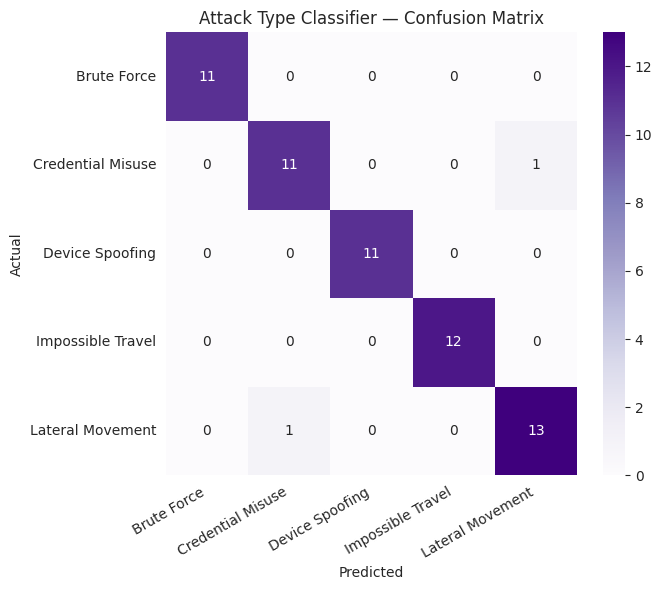

In [19]:
cm2 = confusion_matrix(ya_test, ya_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm2, annot=True, fmt="d", cmap="Purples",
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title("Attack Type Classifier — Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

In [20]:
joblib.dump(clf, f"{MODEL_DIR}/attack_classifier.pkl")
joblib.dump(label_encoder, f"{MODEL_DIR}/attack_label_encoder.pkl")
print("Classifier and label encoder saved to saved_models/")

Classifier and label encoder saved to saved_models/


## 9. Explainability (SHAP)

We use SHAP's `TreeExplainer`, the natural fit for XGBoost — it's exact (not an approximation) and fast for tree ensembles. This answers *why* the classifier picked a given attack type, which we surface per-prediction in the inference pipeline below (Section 10) as the `reasons` field of the SOC alert.

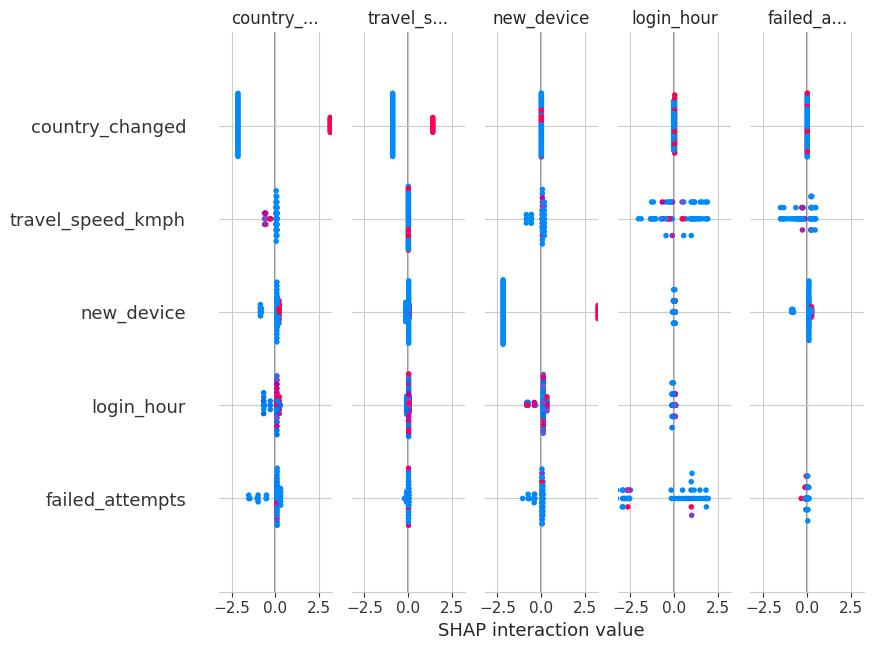

In [21]:
explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(Xa_test_scaled)

# Global feature importance across all attack classes
shap.summary_plot(shap_values, Xa_test_scaled, class_names=label_encoder.classes_, show=False)
plt.tight_layout()
plt.show()

**Observation:** this confirms the EDA — `failed_attempts`, `travel_speed_kmph`, `country_changed`, and `new_device` are the dominant drivers of attack-type predictions, consistent with how a human SOC analyst would reason about these events.

## 10. Inference Pipeline

This is the function a real detection service would call per login event:

```
raw event → feature engineering → Isolation Forest
                                        │
                              anomalous? ── no ──▶ {"prediction": "Normal", "risk_score": low}
                                        │
                                       yes
                                        │
                                        ▼
                              Attack classifier → attack_type, confidence
                                        │
                                        ▼
                              Risk score (0-100) + reasons
```

### Risk score design

The risk score blends five signals into a single 0–100 number a SOC analyst can triage on:

| Component | Weight | Rationale |
|---|---|---|
| Isolation Forest anomaly severity | up to 35 pts | How far outside "normal" the raw geometry says this event is |
| Classifier confidence | up to 25 pts | How sure we are about *which* attack this is (low confidence = ambiguous, still risky but less actionable) |
| Failed login attempts | up to 15 pts | Direct brute-force signal, scaled and capped |
| New device + country changed | up to 15 pts (combined) | Classic account-takeover / impossible-travel indicators |
| Travel speed | up to 5 pts | Physically implausible travel speed (>800 km/h) is a strong impossible-travel signal |
| Sensitive resource access | up to 5 pts | Elevates risk when the anomalous session touched Payroll/Finance |

Scores are clipped to `[0, 100]`. This is a transparent, rule-weighted blend rather than a black-box score — every point is traceable to a `reasons` entry, which matters for SOC trust and for audit/compliance sign-off.

In [22]:
def compute_risk_score(anomaly_score_raw, iso_contamination, confidence, feature_row):
    """Combine model outputs and raw signals into a 0-100 enterprise risk score.

    Parameters
    ----------
    anomaly_score_raw : float
        -iso_forest.decision_function() value for this event (higher = more anomalous).
    iso_contamination : float
        The contamination rate the Isolation Forest was trained with, used to
        normalize the anomaly score onto a roughly comparable scale.
    confidence : float
        Classifier's predicted probability for the top attack_type (0-1). 0 if
        the event wasn't flagged as anomalous.
    feature_row : dict
        The engineered feature values for this single event.

    Returns
    -------
    tuple(int, list[str])
        (risk_score clipped to [0, 100], list of human-readable reasons)
    """
    reasons = []
    score = 0.0

    # 1) Isolation Forest severity, normalized against typical score range (~-0.1 to 0.3)
    severity = np.clip((anomaly_score_raw + 0.1) / 0.4, 0, 1)
    score += severity * 35
    if severity > 0.5:
        reasons.append("Strong behavioral deviation from normal baseline")

    # 2) Classifier confidence
    score += confidence * 25
    if confidence > 0.7:
        reasons.append(f"High classifier confidence ({confidence:.0%})")

    # 3) Failed attempts (capped at 10 attempts -> full 15 pts)
    fa = min(feature_row["failed_attempts"], 10) / 10
    score += fa * 15
    if feature_row["failed_attempts"] >= 3:
        reasons.append(f"{feature_row['failed_attempts']} failed login attempts")

    # 4) New device + country changed (account takeover signal)
    if feature_row["new_device"]:
        score += 7.5
        reasons.append("Login from a new/unrecognized device")
    if feature_row["country_changed"]:
        score += 7.5
        reasons.append("Country changed since last session")

    # 5) Travel speed
    if feature_row["travel_speed_kmph"] > 800:
        score += 5
        reasons.append(f"Travel speed physically implausible ({feature_row['travel_speed_kmph']} km/h)")

    # 6) Sensitive resource access
    if feature_row["sensitive_resource_access"]:
        score += 5
        reasons.append("Accessed a sensitive resource (Payroll/Finance)")

    return int(np.clip(round(score), 0, 100)), reasons


def predict_event(raw_event: dict) -> dict:
    """Run a single raw login event through the full detection pipeline.

    Parameters
    ----------
    raw_event : dict
        Raw event fields: login_hour, failed_attempts, new_device, country_changed,
        travel_speed_kmph, session_duration_min, unique_resources, resource.

    Returns
    -------
    dict
        SOC-style alert: prediction, risk_score, confidence, reasons, is_anomaly.
    """
    raw_df_single = pd.DataFrame([raw_event])
    fe = engineer_features(raw_df_single)[FEATURE_COLUMNS]
    fe_scaled = pd.DataFrame(scaler.transform(fe), columns=FEATURE_COLUMNS)

    anomaly_flag = iso_forest.predict(fe_scaled)[0]  # -1 = anomaly, 1 = normal
    anomaly_score_raw = -iso_forest.decision_function(fe_scaled)[0]
    is_anomaly = anomaly_flag == -1

    if not is_anomaly:
        risk_score, reasons = compute_risk_score(anomaly_score_raw, contamination_rate, 0.0, fe.iloc[0].to_dict())
        return {
            "prediction": "Normal",
            "is_anomaly": False,
            "risk_score": risk_score,
            "confidence": None,
            "reasons": reasons if reasons else ["No significant deviation from baseline behavior"],
        }

    probs = clf.predict_proba(fe_scaled)[0]
    top_idx = int(np.argmax(probs))
    attack_type = label_encoder.inverse_transform([top_idx])[0]
    confidence = float(probs[top_idx])

    risk_score, reasons = compute_risk_score(anomaly_score_raw, contamination_rate, confidence, fe.iloc[0].to_dict())

    return {
        "prediction": attack_type,
        "is_anomaly": True,
        "risk_score": risk_score,
        "confidence": round(confidence, 2),
        "reasons": reasons,
    }

print("Inference pipeline ready: predict_event(raw_event) -> SOC alert dict")

Inference pipeline ready: predict_event(raw_event) -> SOC alert dict


### 10.1 Demo — run the pipeline on real examples from the test set

In [23]:
demo_normal = {
    "login_hour": 10, "failed_attempts": 0, "new_device": 0, "country_changed": 0,
    "travel_speed_kmph": 0, "session_duration_min": 90, "unique_resources": 4,
    "resource": "CRM",
}

demo_attack = {
    "login_hour": 3, "failed_attempts": 6, "new_device": 1, "country_changed": 1,
    "travel_speed_kmph": 950, "session_duration_min": 12, "unique_resources": 9,
    "resource": "Payroll",
}

for name, event in [("Everyday login", demo_normal), ("Suspicious login", demo_attack)]:
    print(f"--- {name} ---")
    print(json.dumps(predict_event(event), indent=4))
    print()

--- Everyday login ---
{
    "prediction": "Normal",
    "is_anomaly": false,
    "risk_score": 0,
    "confidence": null,
    "reasons": [
        "No significant deviation from baseline behavior"
    ]
}

--- Suspicious login ---
{
    "prediction": "Device Spoofing",
    "is_anomaly": true,
    "risk_score": 60,
    "confidence": 0.39,
    "reasons": [
        "6 failed login attempts",
        "Login from a new/unrecognized device",
        "Country changed since last session",
        "Travel speed physically implausible (950 km/h)",
        "Accessed a sensitive resource (Payroll/Finance)"
    ]
}



## 11. Summary

| Component | Purpose | Metric |
|---|---|---|
| Isolation Forest | Detect *whether* an event is anomalous, including unseen attack patterns | See Section 7.1 for Precision / Recall / F1 / ROC AUC |
| XGBoost classifier | Classify *which* attack type, once flagged | See Section 8.1 for Accuracy / Macro-F1 |
| SHAP | Explain classifier decisions globally and per-event | Section 9 |
| `predict_event()` | Production-shaped inference entrypoint returning a SOC alert JSON | Section 10 |

**Why two models instead of one:** a single supervised classifier trained end-to-end on `label` would need to learn "normal vs attack" from only ~3% positive examples, and would be blind to attack patterns not present in training data. Splitting the problem into (1) an unsupervised novelty detector trained purely on normal behavior, and (2) a supervised classifier that only has to distinguish among *known* attack types once something is already flagged, is closer to how real SOC/UEBA tooling (e.g. Splunk UBA, Microsoft Sentinel UEBA) is architected, and is easier to defend to a hackathon panel.

**Next steps for a production deployment** (out of scope for this notebook, worth mentioning in a demo): streaming feature computation instead of batch, periodic Isolation Forest retraining as "normal" drifts, and a feedback loop where SOC analyst triage decisions become new labeled data for the classifier.